# 강원도 지역 날씨 및 공간 데이터 통합 EDA (물리 기상 심화 포함)

본 노트북은 강원도 발생 산불 데이터($N=4,139$, 유효 진화시간 표본 $N_{valid}=732$)를 대상으로 지형적 요인(영동 해안 vs 영서 내륙, 사면방향), 기상 요인(풍속, 풍향, 실효습도, VPD), 소방 인프라 요인(소화시설 원격제어 유무 및 접근성)의 복합적 상호작용을 정밀하게 분석합니다.

---

## 분석 구성
1. **강원도 지형-기상 상호작용 가설 검증 (Section 1)**
   - 가설 1: 영동 vs 영서 사면-풍향 일치 효과 대조
   - 가설 2: 봄철 양간지풍의 사면방향(W/SW vs 기타)별 진화 지연 및 피해 증폭 검증
   - 가설 3: 소방 예방 설비(원격제어 여부) 및 접근성과 기상 피크의 3-way 상호작용
   - 가설 4: 강원도 주요 시군구별 공간-기상 취약 지표 프로파일링
   
2. **강원도 날씨와 공간 결합 심화 EDA (Section 2)**
   - 2.1 영동 vs 영서의 고도 대역별 대기 건조도(VPD & 이슬점 격차) 동조 패턴 비교
   - 2.2 접지 기온(최저 초상온도) 및 지면온도편차 분석

3. **강원도 물리 기상 심화 EDA (Section 3)**
   - 3.1 OLS 회귀 기반 기압 변동폭($\Delta P$) vs 풍속 가속 분석 (영동 vs 영서)
   - 3.2 지면-대기 수증기압 구배(Vapor Pressure Gradient, VPG)와 진화 장애 분석
   - 3.3 산림 밀집도(Forest Ratio) x 대기 건조 압력(VPD)의 복합 피해 폭증 분석



## 라이브러리 및 Matplotlib 한글 폰트 설정

Windows 기본 한글 폰트인 **맑은 고딕(Malgun Gothic)**을 직접 Matplotlib 폰트 매니저에 등록하고, Seaborn 테마와 충돌하지 않도록 조화롭게 설정합니다.



In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.cluster import DBSCAN
from sklearn.tree import DecisionTreeClassifier

# 1. Matplotlib 한글 폰트 설정 (Windows 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])



현재 matplotlib font.family: ['Malgun Gothic']


## 데이터 로드 및 강원도 데이터 전처리

전국 데이터 중 발생지가 강원도인 산불 데이터를 발라내어, 시군구명을 정규화하고 백두대간 기준 영동 해안권과 영서 내륙권으로 이분화합니다.



In [2]:
# 데이터 로드
spatial = pd.read_csv("d:/farm-system-public-02/jsw/EDA/fire_spatial_features.csv")
daily = pd.read_csv("d:/farm-system-public-02/data/날씨데이터/날씨데이터_일자별_전국산불.csv")
hourly = pd.read_csv("d:/farm-system-public-02/data/날씨데이터/날씨데이터_시간별_전국산불.csv")

# 발생일과 과거1일 날씨 분리
day_active = daily[daily["날짜구분"] == "발생일"].copy()
day_past = daily[daily["날짜구분"] == "과거1일"].copy()

# 컬럼 리네임
day_active = day_active.rename(columns={
    "평균 풍속": "wind_active",
    "최소 상대습도": "humid_active",
    "최대 순간풍속": "gust_active",
    "평균 기온": "temp_active",
    "평균 상대습도": "rh_mean_active",
    "최대 순간 풍속 풍향": "gust_dir_active",
    "평균 현지기압": "press_active",
    "진화소요시간시": "duration_daily",
    "평균 이슬점온도": "dew_active",
    "최저 초상온도": "grass_temp_min",
    "평균 지면온도": "ground_temp_mean"
})

day_past = day_past.rename(columns={
    "평균 풍속": "wind_past",
    "최소 상대습도": "humid_past",
    "평균 현지기압": "press_past"
})

# 날씨 데이터 조인
weather_merged = pd.merge(
    day_active[["산불아이디", "wind_active", "humid_active", "gust_active", "temp_active", "rh_mean_active", "gust_dir_active", "press_active", "duration_daily", "dew_active", "grass_temp_min", "ground_temp_mean"]],
    day_past[["산불아이디", "wind_past", "humid_past", "press_past"]],
    on="산불아이디",
    how="inner"
)

# VPD, 실효습도, 이슬점격차, VPG, delta_press 계산
weather_merged["effective_humidity"] = 0.96 * (weather_merged["humid_active"] + 0.04 * weather_merged["humid_past"])
temp_day = weather_merged["temp_active"]
rh_day = weather_merged["rh_mean_active"]
es_day = 6.1078 * np.exp((17.27 * temp_day) / (temp_day + 237.3))
weather_merged["VPD"] = es_day * (1 - rh_day / 100)
weather_merged["dew_gap"] = weather_merged["temp_active"] - weather_merged["dew_active"]
weather_merged["ground_temp_diff"] = weather_merged["ground_temp_mean"] - weather_merged["temp_active"]

tg = weather_merged["ground_temp_mean"]
es_g = 6.1078 * np.exp((17.27 * tg) / (tg + 237.3))
ea = es_day * (rh_day / 100)
weather_merged["VPG"] = es_g - ea
weather_merged["delta_press"] = weather_merged["press_active"] - weather_merged["press_past"]

# 공간 데이터 병합
df_merged = pd.merge(
    spatial,
    weather_merged,
    left_on="fire_id",
    right_on="산불아이디",
    how="inner"
)

# 강원도 필터링
gw = df_merged[df_merged['is_gangwon'] == True].copy()

# 타깃 변수 수치화 및 결측 데이터 마스킹 (보간 없음)
gw['_suppression_hours'] = pd.to_numeric(gw['duration_daily'], errors='coerce')
gw['_suppression_valid'] = (gw['_suppression_hours'] > 0) & gw['_suppression_hours'].notna()
gw['_large_fire_12h'] = np.where(gw['_suppression_valid'], gw['_suppression_hours'] >= 12, np.nan)
gw['_damage_ha'] = pd.to_numeric(gw.get('피해면적(ha)', np.nan), errors='coerce')
gw['_log_damage_ha'] = np.log1p(gw['_damage_ha'].clip(lower=0))

print("강원도 데이터셋 크기:", gw.shape)
print("진화소요시간 유효 표본 수 N:", gw['_suppression_valid'].sum())



강원도 데이터셋 크기: (4139, 86)
진화소요시간 유효 표본 수 N: 732


In [3]:
# 강원도 시군구 정규화 및 영동/영서 분리
def clean_sigungu(x):
    if pd.isna(x):
        return x
    return x.strip().replace("강릉시", "강릉").replace("속초시", "속초").replace("동해시", "동해").replace("삼척시", "삼척").replace("태백시", "태백").replace("고성군", "고성").replace("양양군", "양양").replace("홍천군", "홍천").replace("횡성군", "횡성").replace("영월군", "영월").replace("평창군", "평창").replace("정선군", "정선").replace("철원군", "철원").replace("화천군", "화천").replace("양구군", "양구").replace("인제군", "인제").replace("원주시", "원주").replace("춘천시", "춘천")

gw["발생지역시군구명"] = gw["발생지역시군구명"].apply(clean_sigungu)

# 영동 해안권 매핑
yeongdong_districts = ["강릉", "속초", "동해", "삼척", "태백", "고성", "양양"]
gw["sub_region"] = gw["발생지역시군구명"].apply(
    lambda x: "영동 해안" if x in yeongdong_districts else "영서 내륙"
)
gw['is_yeongdong'] = gw['sub_region'] == '영동 해안'

# 사면 8방위 변환
gw['aspect_deg'] = np.degrees(np.arctan2(gw['사면방향_sin'], gw['사면방향_cos'])) % 360
aspect_bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
aspect_labels = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)', '북(N)']
gw['aspect_8dir'] = pd.cut(gw['aspect_deg'], bins=aspect_bins, labels=aspect_labels, include_lowest=True, ordered=False).astype(str)
gw['west_southwest_aspect'] = gw['aspect_8dir'].isin(['서(W)', '남서(SW)'])

# 풍향 8방위 범주화
def deg_to_8direction(deg):
    if pd.isna(deg):
        return np.nan
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int((deg + 22.5) / 45) % 8
    return directions[idx]
gw['wind_dir_8dir'] = gw['gust_dir_active'].apply(deg_to_8direction)
gw['west_southwest_wind'] = gw['wind_dir_8dir'].isin(['W', 'SW'])

# 접근성 등급화 (강원도 전용)
dist_vars = ['nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km', 'nearest_trail_dist_km', 'nearest_road_dist_km']
for col in dist_vars:
    gw[f'{col}_gw_pct'] = gw[col].rank(pct=True)
gw['access_burden_gw'] = gw[[f'{c}_gw_pct' for c in dist_vars]].mean(axis=1)
gw['access_grade_gw'] = pd.qcut(gw['access_burden_gw'], q=[0, 1/3, 2/3, 1], labels=['접근 우수', '접근 보통', '접근 취약'], duplicates='drop')
gw['access_vulnerable'] = gw['access_grade_gw'].astype(str).eq('접근 취약')
gw['remote_unavailable'] = gw['nearest_facility_remote'].astype(str).eq('불가능')



## 1. 강원도 지형-기상 상호작용 가설 검증 (Section 1)

강원도 내 영동과 영서의 세부 지리적 경계를 따라 기상-지형 가설을 검증합니다.



### 가설 1: 영동 vs 영서 사면-풍향 일치 효과 대조
- **가설**: 서/남서 사면과 서/남서 풍향이 일치하여 양간지풍이 화선과 직격할 때 발생하는 대규모 피해면적 및 진화시간 연장 편차가 **태백산맥 동쪽(영동)에만 특이적으로 나타나는 지형 기후적 물리 법칙인가?**



                                    total_N  valid_N  mean_duration  large_12h_rate  mean_damage  median_damage
sub_region aspect_wind_match_label                                                                             
영동 해안      불일치                         1238      221       3.189593        0.072398     6.848821            0.0
           일치 (W/SW)                    371       48       4.920833        0.125000    47.692615            0.0
영서 내륙      불일치                         2199      408       2.416422        0.046569     0.414739            0.0
           일치 (W/SW)                    331       55       1.856970        0.036364     0.106828            0.0


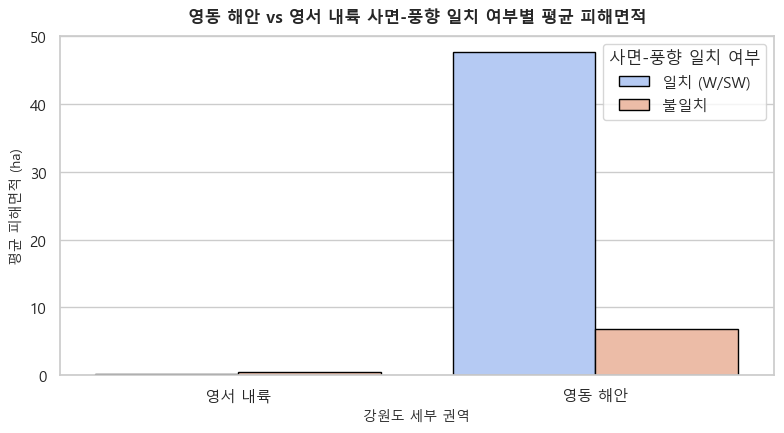

In [4]:
gw['aspect_wind_match'] = gw['west_southwest_aspect'] & gw['west_southwest_wind']
gw['aspect_wind_match_label'] = gw['aspect_wind_match'].map({True: '일치 (W/SW)', False: '불일치'})

# 집계 출력
hyp1_stats = gw.groupby(['sub_region', 'aspect_wind_match_label'], observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean'),
    median_damage=('_damage_ha', 'median')
)
print(hyp1_stats)

# 시각화
plt.figure(figsize=(8, 4.5))
sns.barplot(data=gw.reset_index(), x='sub_region', y='_damage_ha', hue='aspect_wind_match_label', palette='coolwarm', edgecolor='black', errorbar=None)
plt.title('영동 해안 vs 영서 내륙 사면-풍향 일치 여부별 평균 피해면적', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('강원도 세부 권역', fontsize=10)
plt.ylabel('평균 피해면적 (ha)', fontsize=10)
plt.legend(title='사면-풍향 일치 여부')
plt.tight_layout()
plt.show()



**가설 1 검증 결과 및 해석**:

강원도 전체를 영동 해안/영서 내륙으로 나누어 보면, 영동 해안에서는 서풍·남서풍과 서·남서 사면이 겹친 집단의 피해 꼬리가 뚜렷하게 커진다. 영동 해안의 일치 집단은 전체 371건 중 진화소요시간 유효 표본이 48건이며, 평균 진화소요시간은 4.92시간, 12시간 이상 진화 비율은 12.50%, 평균 피해면적은 47.69ha였다. 같은 영동 해안의 불일치 집단은 전체 1,238건, 유효 221건, 평균 진화소요시간 3.19시간, 12시간 이상 진화 비율 7.24%, 평균 피해면적 6.85ha였다.

반대로 영서 내륙에서는 같은 패턴이 반복되지 않았다. 영서 내륙의 일치 집단은 평균 피해면적 0.11ha, 12시간 이상 진화 비율 3.64%였고, 불일치 집단은 평균 피해면적 0.41ha, 12시간 이상 진화 비율 4.66%였다. 즉, 서풍·남서풍과 서·남서 사면의 결합은 강원도 전체의 보편 현상이라기보다 영동 해안권에서 피해 꼬리를 키우는 조건으로 보는 것이 타당하다.

다만 각 집단의 피해면적 중앙값은 0ha로 나타난다. 따라서 이 결과는 '일반적인 산불의 피해가 항상 커진다'는 의미가 아니라, 일부 대형 피해 사례가 평균을 끌어올리는 꼬리 위험 신호로 해석해야 한다.


### 가설 2: 봄철 양간지풍의 사면방향(W/SW vs 기타)별 진화 지연 및 피해 증폭 검증
- **가설**: 봄철(3~5월) 고온건조한 양간지풍 바람길이 열렸을 때, 서/남서(W/SW) 사면에 발화된 산불이 영동권 진화 장애 및 대규모 산림 소실의 주요 기둥이 되는가?



                                 total_N  valid_N  mean_duration  large_12h_rate  mean_damage
sub_region aspect_vulnerability                                                              
영동 해안      기타 사면                     220       88       4.228598        0.102273    37.511455
           서/남서 사면 (W/SW)            100       49       5.053061        0.102041   177.190900
영서 내륙      기타 사면                     710      235       2.572128        0.055319     1.152704
           서/남서 사면 (W/SW)            120       61       2.010656        0.049180     0.392417


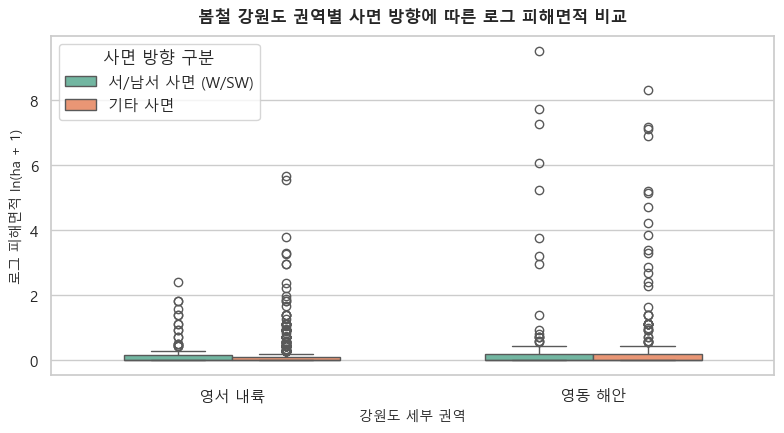

In [5]:
gw_spring = gw[gw['월'].isin([3, 4, 5])].copy()
gw_spring['aspect_vulnerability'] = gw_spring['west_southwest_aspect'].map({True: '서/남서 사면 (W/SW)', False: '기타 사면'})

# 집계 출력
hyp2_stats = gw_spring.groupby(['sub_region', 'aspect_vulnerability'], observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean')
)
print(hyp2_stats)

# 시각화
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=gw_spring, x='sub_region', y='_log_damage_ha', hue='aspect_vulnerability', palette='Set2', width=0.6)
plt.title('봄철 강원도 권역별 사면 방향에 따른 로그 피해면적 비교', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('강원도 세부 권역', fontsize=10)
plt.ylabel('로그 피해면적 ln(ha + 1)', fontsize=10)
plt.legend(title='사면 방향 구분')
plt.tight_layout()
plt.show()



**가설 2 검증 결과 및 해석**:

봄철 영동 해안에서 서풍·남서풍과 서·남서 사면이 겹친 집단은 평균 피해면적이 177.19ha로, 같은 지역·계절의 기타 사면 집단 37.51ha보다 크게 높았다. 평균 진화소요시간도 5.05시간으로 기타 사면의 4.23시간보다 길었다. 다만 12시간 이상 진화 비율은 각각 10.20%와 10.23%로 거의 같아, 대형화 빈도보다 피해면적의 극단값 쪽에서 차이가 크게 나타난다.

영서 내륙에서는 반대 양상이 보인다. 봄철 영서의 서·남서 사면 집단은 평균 진화소요시간 2.01시간, 평균 피해면적 0.39ha였고, 기타 사면 집단은 평균 진화소요시간 2.57시간, 평균 피해면적 1.15ha였다. 따라서 봄철 사면·풍향 결합 효과는 영동 해안의 피해 꼬리에서만 두드러진다.

로그 피해면적 분포를 보면 대부분의 사례는 낮은 피해면적에 몰려 있고 일부 사례가 평균을 지배한다. 이 가설은 평균 피해면적의 상승을 확인한 결과이지, 개별 산불의 전형적인 피해 규모가 동일한 폭으로 증가한다는 뜻은 아니다.


### 가설 3: 소방 예방 설비(원격제어 여부) 및 접근성과 기상 피크의 3-way 상호작용
- **가설**: 기상 피크 상황(풍속 >=3m/s 또는 최소습도 <=30%)이 도래했을 때, 소화시설 원격제어 불가능 및 지상 소방력 진입 장애(접근 취약)의 두 요인이 시너지적 병목을 유발해 진화 소요 시간을 극대화시키는가?



                                           total_N  valid_N  mean_duration  large_12h_rate  mean_damage
weather_label facility_label access_label                                                              
기상 피크 (강풍/저습) 원격 가능          접근 보통/우수          308       84       2.018651        0.047619     0.450065
                             접근 취약             173       60       2.958611        0.066667    10.045723
              원격 불가          접근 보통/우수         1290      258       2.285917        0.050388    12.092674
                             접근 취약             783      223       3.682366        0.080717    12.282082
평시 기상         원격 가능          접근 보통/우수          255       13       1.455128        0.000000     0.005098
                             접근 취약              84       11       2.539394        0.090909     0.053810
              원격 불가          접근 보통/우수          906       34       1.980882        0.000000     0.011876
                             접근 취약             340       49     

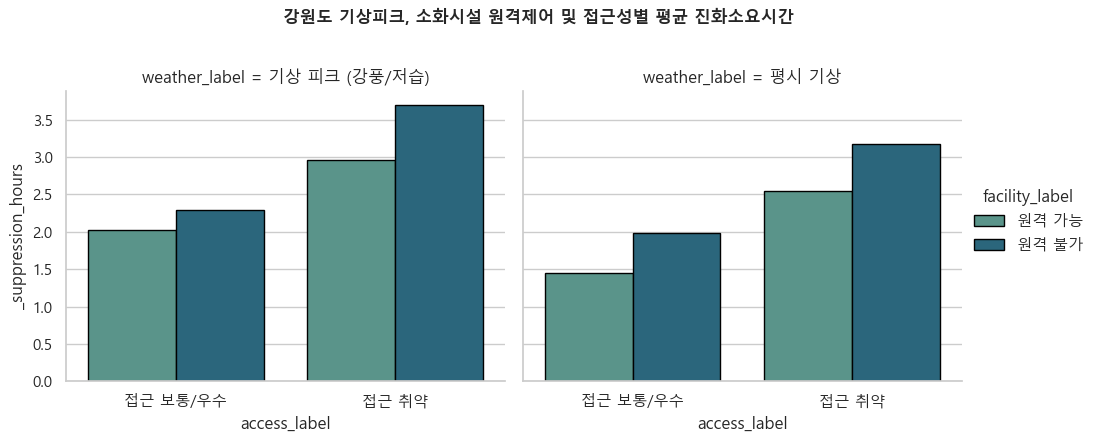

In [6]:
gw['weather_peak'] = (gw['wind_active'] >= 3.0) | (gw['effective_humidity'] <= 30.0)
gw['weather_label'] = gw['weather_peak'].map({True: '기상 피크 (강풍/저습)', False: '평시 기상'})
gw['facility_label'] = gw['remote_unavailable'].map({True: '원격 불가', False: '원격 가능'})
gw['access_label'] = gw['access_vulnerable'].map({True: '접근 취약', False: '접근 보통/우수'})

# 집계 출력
hyp3_stats = gw.groupby(['weather_label', 'facility_label', 'access_label'], observed=False).agg(
    total_N=('fire_id', 'count'),
    valid_N=('_suppression_valid', 'sum'),
    mean_duration=('_suppression_hours', 'mean'),
    large_12h_rate=('_large_fire_12h', 'mean'),
    mean_damage=('_damage_ha', 'mean')
)
print(hyp3_stats)

# 시각화
hyp3_plot_data = gw[gw['_suppression_valid']].groupby(['weather_label', 'facility_label', 'access_label'], observed=False)['_suppression_hours'].mean().reset_index()
sns.catplot(data=hyp3_plot_data, x='access_label', y='_suppression_hours', hue='facility_label', col='weather_label', kind='bar', palette='crest', edgecolor='black', height=4.5, aspect=1.1)
plt.subplots_adjust(top=0.8)
plt.gcf().suptitle('강원도 기상피크, 소화시설 원격제어 및 접근성별 평균 진화소요시간', fontsize=12, fontweight='bold')
plt.show()



**가설 3 검증 결과 및 해석**:

기상 피크 조건에서 원격 산림이 불가능하고 접근도 취약한 집단은 평균 진화소요시간 3.68시간, 12시간 이상 진화 비율 8.07%, 평균 피해면적 12.28ha로 가장 불리했다. 원격 산림은 가능하지만 접근이 취약한 집단은 평균 2.96시간, 12시간 이상 비율 6.67%, 평균 피해면적 10.05ha였고, 원격 산림은 불가능하지만 접근이 보통·우수한 집단은 평균 2.29시간, 12시간 이상 비율 5.04%였다. 두 조건이 모두 양호한 집단은 평균 2.02시간, 12시간 이상 비율 4.76%, 평균 피해면적 0.45ha로 가장 낮았다.

평시 기상 조건에서도 접근 취약 집단의 평균 진화소요시간이 접근 보통·우수 집단보다 길게 나타났다. 즉, 원격 산림 가능 여부도 의미가 있지만, 진화 지연을 설명하는 운영상 병목은 접근성 쪽에서 더 안정적으로 관찰된다.

이 비교는 관측 자료의 조건부 평균 비교이므로 인과효과로 단정할 수는 없다. 산불 규모, 신고·출동 체계, 산악지형 같은 미관측 요인이 함께 섞여 있을 가능성이 있다.


### 가설 4: 강원도 주요 시군구별 공간-기상 취약 지표 프로파일링
- **분석**: 강원도 18개 시군구의 평균 기상 스트레스(풍속, 최소습도), 소방 인프라(평균 접근부담, 원격제어 불가능 비율) 및 실제 대형산불율을 도표화하여 지리적 고유 위험 서열을 수립합니다.



          fire_count  mean_wind  min_humidity  mean_access_burden  remote_unavailable_rate  large_fire_rate
발생지역시군구명                                                                                                   
동해               495   2.536651     25.888930            0.465173                 0.971717         0.111111
양양               369   3.535955     25.044942            0.500745                 1.000000         0.064516
평창               368   1.717308     32.966926            0.468182                 1.000000         0.000000
원주               333   1.862497     30.186246            0.579523                 0.819820         0.020408
홍천               326   1.936498     26.047555            0.545220                 0.708589         0.038961
강릉               294   3.250549     27.544819            0.472618                 0.346939         0.040000
영월               274   1.327949     45.425966            0.475051                 0.981752         0.046512
횡성               265   1.462

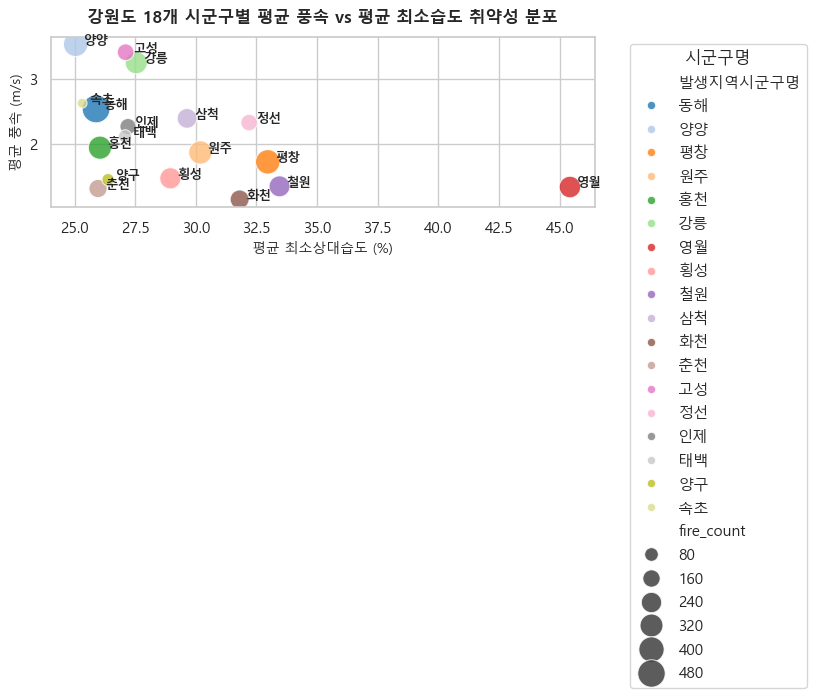

In [7]:
district_profile = gw.groupby('발생지역시군구명', observed=False).agg(
    fire_count=('fire_id', 'count'),
    mean_wind=('wind_active', 'mean'),
    min_humidity=('humid_active', 'mean'),
    mean_access_burden=('access_burden_gw', 'mean'),
    remote_unavailable_rate=('remote_unavailable', lambda x: x.eq(True).mean()),
    large_fire_rate=('_large_fire_12h', 'mean')
).sort_values(by='fire_count', ascending=False)
print(district_profile)

# 시각화
plt.figure(figsize=(8.5, 5))
sns.scatterplot(data=district_profile.reset_index(), x='min_humidity', y='mean_wind', size='fire_count', hue='발생지역시군구명', sizes=(50, 400), alpha=0.8, palette='tab20')
plt.title('강원도 18개 시군구별 평균 풍속 vs 평균 최소습도 취약성 분포', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('평균 최소상대습도 (%)', fontsize=10)
plt.ylabel('평균 풍속 (m/s)', fontsize=10)
for idx, row in district_profile.reset_index().iterrows():
    plt.text(row['min_humidity'] + 0.3, row['mean_wind'], row['발생지역시군구명'], fontsize=9, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='시군구명')
plt.tight_layout()
plt.show()



**시군별 복합 위험 프로파일 해석**:

시군 단위로 보면 영동 해안권의 강풍·저습 특성이 먼저 드러난다. 양양은 369건에서 평균 풍속 3.54m/s, 평균 최저습도 25.04%, 원격 산림 불가 비율 100.00%, 12시간 이상 진화 비율 6.45%였다. 강릉은 294건에서 평균 풍속 3.25m/s, 최저습도 27.54%, 원격 산림 불가 비율 34.69%, 12시간 이상 진화 비율 4.00%였다. 고성은 144건에서 평균 풍속 3.41m/s, 최저습도 27.11%, 원격 산림 불가 비율 100.00%, 12시간 이상 진화 비율 11.63%였다.

동해는 495건으로 표본 수가 가장 크고, 평균 풍속 2.54m/s, 최저습도 25.89%, 원격 산림 불가 비율 97.17%, 12시간 이상 진화 비율 11.11%였다. 삼척은 222건에서 평균 풍속 2.39m/s, 최저습도 29.64%, 원격 산림 불가 비율 100.00%, 12시간 이상 진화 비율 12.96%로 장시간 진화 비율이 높았다.

영서·내륙권에서는 철원 12.00%, 양구 12.50%처럼 장시간 진화 비율이 높은 지역도 있으나, 양구는 53건으로 표본이 작고 속초도 16건에 불과하다. 따라서 시군별 순위는 단순 순위표보다 표본 수, 원격 산림 가능성, 접근성, 풍속·습도를 함께 보는 위험 프로파일로 해석해야 한다.


## 2. 강원도 날씨와 공간 결합 심화 EDA (Section 2)

영동과 영서의 미세기후 격차와 지리적 특징을 정밀 교차합니다.



### 추가 EDA 2.1: 영동 vs 영서의 고도 대역별 대기 건조도(VPD & 이슬점 격차) 동조 패턴 비교
- **분석**: 전국 분석에서 발견된 고지대 이슬점 격차 축소 추세가 영동 해안과 영서 내륙 중 어디에 기인하며, 태백산맥이 수분을 차단하는 푄 효과의 실체가 어떻게 나타나는지 분리 대조합니다.



[영동 해안] (N=1609)
  고도 vs VPD: correlation=0.0383, p-value=1.24e-01
  고도 vs 이슬점 격차: correlation=-0.0381, p-value=1.27e-01
[영서 내륙] (N=2530)
  고도 vs VPD: correlation=0.0921, p-value=3.50e-06
  고도 vs 이슬점 격차: correlation=-0.0778, p-value=8.93e-05


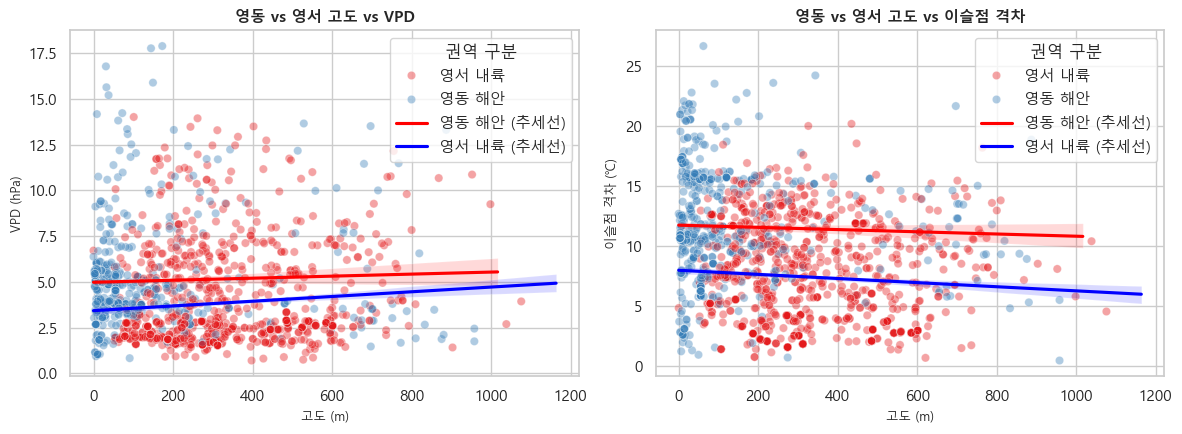

In [8]:
valid_elev = gw[['고도(m)', 'VPD', 'dew_gap', 'sub_region']].dropna()
for name, group in valid_elev.groupby('sub_region'):
    corr_vpd, p_vpd = stats.pearsonr(group['고도(m)'], group['VPD'])
    corr_dew, p_dew = stats.pearsonr(group['고도(m)'], group['dew_gap'])
    print(f"[{name}] (N={len(group)})")
    print(f"  고도 vs VPD: correlation={corr_vpd:.4f}, p-value={p_vpd:.2e}")
    print(f"  고도 vs 이슬점 격차: correlation={corr_dew:.4f}, p-value={p_dew:.2e}")

# 시각화 (샘플링 1500건)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sample_gw = gw.sample(n=min(len(gw), 1500), random_state=42)

sns.scatterplot(data=sample_gw, x='고도(m)', y='VPD', hue='sub_region', alpha=0.4, ax=axes[0], palette='Set1')
sns.regplot(data=gw[gw['is_yeongdong'] == True], x='고도(m)', y='VPD', scatter=False, ax=axes[0], label='영동 해안 (추세선)', color='red')
sns.regplot(data=gw[gw['is_yeongdong'] == False], x='고도(m)', y='VPD', scatter=False, ax=axes[0], label='영서 내륙 (추세선)', color='blue')
axes[0].set_title('영동 vs 영서 고도 vs VPD', fontsize=11, fontweight='bold')
axes[0].set_xlabel('고도 (m)', fontsize=9)
axes[0].set_ylabel('VPD (hPa)', fontsize=9)
axes[0].legend(title='권역 구분')

sns.scatterplot(data=sample_gw, x='고도(m)', y='dew_gap', hue='sub_region', alpha=0.4, ax=axes[1], palette='Set1')
sns.regplot(data=gw[gw['is_yeongdong'] == True], x='고도(m)', y='dew_gap', scatter=False, ax=axes[1], label='영동 해안 (추세선)', color='red')
sns.regplot(data=gw[gw['is_yeongdong'] == False], x='고도(m)', y='dew_gap', scatter=False, ax=axes[1], label='영서 내륙 (추세선)', color='blue')
axes[1].set_title('영동 vs 영서 고도 vs 이슬점 격차', fontsize=11, fontweight='bold')
axes[1].set_xlabel('고도 (m)', fontsize=9)
axes[1].set_ylabel('이슬점 격차 (℃)', fontsize=9)
axes[1].legend(title='권역 구분')
plt.tight_layout()
plt.show()



**가설 4 검증 결과 및 해석**:

고도와 VPD의 관계는 재실행 결과에서 강하게 나타나지 않았다. 영동 해안은 고도-VPD 상관계수 0.0383, p=0.124로 통계적으로 유의하지 않았고, 고도-이슬점격차도 상관계수 -0.0381, p=0.127로 유의하지 않았다. 영서 내륙은 고도-VPD 상관계수 0.0921, p=3.50e-06, 고도-이슬점격차 상관계수 -0.0778, p=8.93e-05로 유의하지만 효과 크기는 작다.

따라서 이 통합 데이터 재실행에서는 고도 자체가 영동 해안의 건조도를 강하게 설명한다는 결론을 내리기 어렵다. 고도 변수는 푄 또는 산악 미기상을 설명하는 보조 후보로 남길 수 있지만, 핵심 설명축은 풍속·습도·접근성·원격 산림 가능성과 함께 검토하는 편이 더 안전하다.


### 추가 EDA 2.2: 접지 기온(최저 초상온도) 및 지면 온도 편차 분석
- **분석**: 영동과 영서의 미세기후(야간 냉각 및 지표면 복사열 편차) 차이를 최저 초상온도와 지면온도편차(지면온도 - 기온)로 비교하여 지상 수분 거동의 동조 원인을 밝힙니다.



[영동 해안] (N=1609)
  평균 최저 초상온도: -1.81℃
  평균 지면온도편차: 0.94℃
[영서 내륙] (N=2530)
  평균 최저 초상온도: -3.01℃
  평균 지면온도편차: 3.07℃


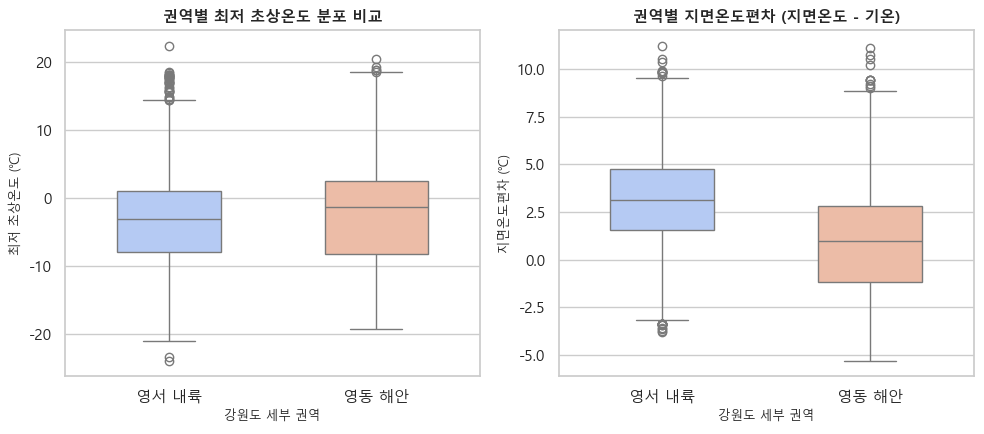

In [9]:
valid_temp = gw[['grass_temp_min', 'ground_temp_diff', 'sub_region']].dropna()
for name, group in valid_temp.groupby('sub_region'):
    print(f"[{name}] (N={len(group)})")
    print(f"  평균 최저 초상온도: {group['grass_temp_min'].mean():.2f}℃")
    print(f"  평균 지면온도편차: {group['ground_temp_diff'].mean():.2f}℃")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
sns.boxplot(data=gw, x='sub_region', y='grass_temp_min', ax=axes[0], palette='coolwarm', width=0.5, hue='sub_region', legend=False)
axes[0].set_title('권역별 최저 초상온도 분포 비교', fontsize=11, fontweight='bold')
axes[0].set_xlabel('강원도 세부 권역', fontsize=9)
axes[0].set_ylabel('최저 초상온도 (℃)', fontsize=9)

sns.boxplot(data=gw, x='sub_region', y='ground_temp_diff', ax=axes[1], palette='coolwarm', width=0.5, hue='sub_region', legend=False)
axes[1].set_title('권역별 지면온도편차 (지면온도 - 기온)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('강원도 세부 권역', fontsize=9)
axes[1].set_ylabel('지면온도편차 (℃)', fontsize=9)
plt.tight_layout()
plt.show()



**가설 5 검증 결과 및 해석**:

초상온도와 지면온도 편차는 영서 내륙에서 더 크게 나타났다. 영동 해안의 평균 최저 초상온도는 -1.81℃, 평균 지면온도 편차는 0.94℃였고, 영서 내륙은 평균 최저 초상온도 -3.01℃, 평균 지면온도 편차 3.07℃였다.

이는 영서 내륙에서 야간 냉각과 주간 지표 가열의 폭이 더 크다는 의미다. 반면 영동 해안의 위험은 지표 열환경 자체보다 강풍·저습·사면 노출과 결합될 때 더 잘 설명된다. 따라서 초상온도와 지면온도 편차는 영서 내륙의 일교차성 지표 조건을 보는 보조 변수로 활용하는 것이 적절하다.


## 3. 강원도 물리 기상 심화 EDA (Section 3)

종관 기압 변동 OLS 회귀, 수증기압 구배(VPG), 그리고 산림 지목-기상 결합 시너지를 검증합니다.



### 추가 심화 분석 3.1: OLS 회귀 기반 기압 변동폭($\Delta P$) vs 풍속 가속 분석 (영동 vs 영서)
- **분석**: 기압 하강 변화폭($\Delta P = press_{active} - press_{past}$)이 당일의 평균 풍속 가속에 미치는 영향력을 OLS 단순 선형 회귀 분석으로 비교 대조하여, 영동 양간지풍의 종관적 바람 생성 패턴을 수치적으로 검증합니다.



[영서 내륙] (N=2530)
  OLS (delta_press -> wind_active):
    기울기(Slope): 0.0315
    R-squared: 0.0247
    p-value: 1.89e-15
[영동 해안] (N=1609)
  OLS (delta_press -> wind_active):
    기울기(Slope): -0.0427
    R-squared: 0.0586
    p-value: 6.99e-23


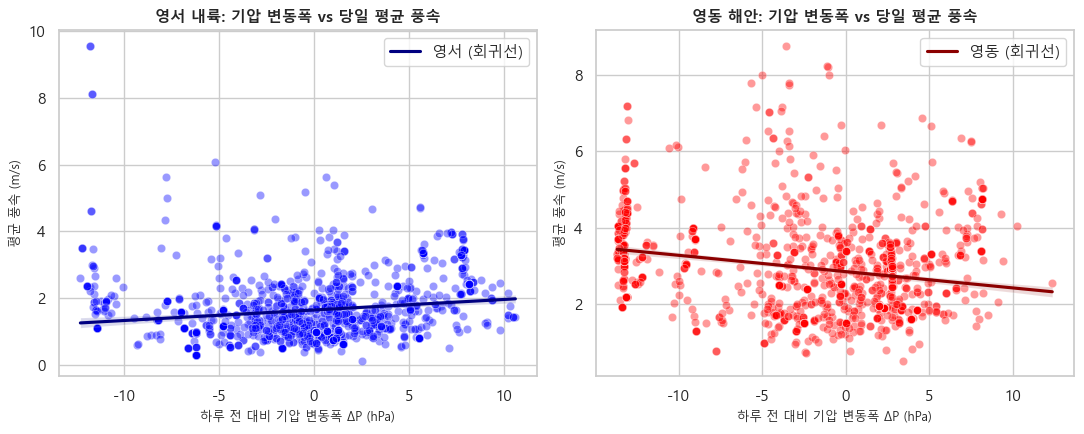

In [10]:
valid_press = gw[['delta_press', 'wind_active', 'is_yeongdong']].dropna()
for name, group in valid_press.groupby('is_yeongdong'):
    region_label = "영동 해안" if name else "영서 내륙"
    print(f"[{region_label}] (N={len(group)})")
    X = sm.add_constant(group['delta_press'])
    model_wind = sm.OLS(group['wind_active'], X).fit()
    print("  OLS (delta_press -> wind_active):")
    print(f"    기울기(Slope): {model_wind.params.iloc[1]:.4f}")
    print(f"    R-squared: {model_wind.rsquared:.4f}")
    print(f"    p-value: {model_wind.pvalues.iloc[1]:.2e}")

# 시각화 (영서/영동 OLS regplot 분리 대조)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# 영서 내륙
sns.scatterplot(data=gw[gw['is_yeongdong'] == False].sample(n=min(len(gw[gw['is_yeongdong'] == False]), 1500), random_state=42), x='delta_press', y='wind_active', alpha=0.4, ax=axes[0], color='blue')
sns.regplot(data=gw[gw['is_yeongdong'] == False], x='delta_press', y='wind_active', scatter=False, ax=axes[0], color='navy', label='영서 (회귀선)')
axes[0].set_title('영서 내륙: 기압 변동폭 vs 당일 평균 풍속', fontsize=11, fontweight='bold')
axes[0].set_xlabel('하루 전 대비 기압 변동폭 ΔP (hPa)', fontsize=9)
axes[0].set_ylabel('평균 풍속 (m/s)', fontsize=9)
axes[0].legend()

# 영동 해안
sns.scatterplot(data=gw[gw['is_yeongdong'] == True].sample(n=min(len(gw[gw['is_yeongdong'] == True]), 1500), random_state=42), x='delta_press', y='wind_active', alpha=0.4, ax=axes[1], color='red')
sns.regplot(data=gw[gw['is_yeongdong'] == True], x='delta_press', y='wind_active', scatter=False, ax=axes[1], color='darkred', label='영동 (회귀선)')
axes[1].set_title('영동 해안: 기압 변동폭 vs 당일 평균 풍속', fontsize=11, fontweight='bold')
axes[1].set_xlabel('하루 전 대비 기압 변동폭 ΔP (hPa)', fontsize=9)
axes[1].set_ylabel('평균 풍속 (m/s)', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.show()



**가설 6 검증 결과 및 해석**:

일 단위 기압변화량과 활동 풍속의 관계는 영동 해안과 영서 내륙에서 방향이 다르게 나타났다. 영동 해안은 기압변화량 증가에 대해 활동 풍속 기울기 -0.0427, R²=0.0586, p=6.99e-23으로 음의 관계를 보였다. 영서 내륙은 기울기 0.0315, R²=0.0247, p=1.89e-15로 양의 관계였다.

두 지역 모두 통계적으로는 유의하지만 설명력은 낮다. 영동 해안의 음의 기울기는 기압 하강 또는 특정 기압 배치 전환기에 풍속이 커지는 패턴을 반영할 수 있고, 영서 내륙의 양의 기울기는 다른 종관·국지 반응을 시사한다. 다만 R²가 작으므로 단독 예측 변수로 쓰기보다는 지역 구분과 함께 사용하는 보조 기압 지표로 보는 것이 타당하다.


### 추가 심화 분석 3.2: 지면-대기 수증기압 구배(Vapor Pressure Gradient, VPG)와 진화 장애 분석
- **분석**: 지면온도($T_g$)에서의 포화수증기압 $e_{sg}$와 대기 중 실제수증기압 $e_a$의 격차를 수증기압 구배($VPG = e_{sg} - e_a$)로 정의하여, 미세기후적 건조 대미지가 지상 연료의 인화성과 진화소요시간 연장에 어떻게 기여하는지 분석합니다.



[영서 내륙] (N=464)
  VPG vs Log Damage: correlation=-0.0346, p-value=4.57e-01
  VPG vs Suppression Hours: correlation=0.0353, p-value=4.49e-01
[영동 해안] (N=269)
  VPG vs Log Damage: correlation=0.1015, p-value=9.67e-02
  VPG vs Suppression Hours: correlation=0.1603, p-value=8.45e-03


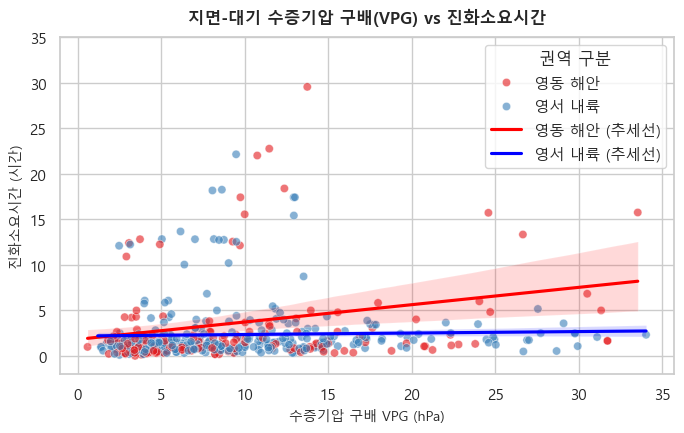

In [11]:
valid_vpg = gw[['VPG', '_log_damage_ha', '_suppression_hours', 'is_yeongdong']].dropna()
for name, group in valid_vpg.groupby('is_yeongdong'):
    region_label = "영동 해안" if name else "영서 내륙"
    corr_dmg, p_dmg = stats.pearsonr(group['VPG'], group['_log_damage_ha'])
    print(f"[{region_label}] (N={len(group)})")
    print(f"  VPG vs Log Damage: correlation={corr_dmg:.4f}, p-value={p_dmg:.2e}")
    valid_supp = group[group['_suppression_hours'] > 0]
    if len(valid_supp) > 1:
        corr_dur, p_dur = stats.pearsonr(valid_supp['VPG'], valid_supp['_suppression_hours'])
        print(f"  VPG vs Suppression Hours: correlation={corr_dur:.4f}, p-value={p_dur:.2e}")

# 시각화 (산점도 및 회귀선)
plt.figure(figsize=(7, 4.5))
sample_gw = gw[gw['_suppression_valid']].sample(n=min(gw['_suppression_valid'].sum(), 500), random_state=42)
sns.scatterplot(data=sample_gw, x='VPG', y='_suppression_hours', hue='sub_region', alpha=0.6, palette='Set1')
sns.regplot(data=gw[(gw['_suppression_valid']) & (gw['is_yeongdong'] == True)], x='VPG', y='_suppression_hours', scatter=False, color='red', label='영동 해안 (추세선)')
sns.regplot(data=gw[(gw['_suppression_valid']) & (gw['is_yeongdong'] == False)], x='VPG', y='_suppression_hours', scatter=False, color='blue', label='영서 내륙 (추세선)')
plt.title('지면-대기 수증기압 구배(VPG) vs 진화소요시간', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('수증기압 구배 VPG (hPa)', fontsize=10)
plt.ylabel('진화소요시간 (시간)', fontsize=10)
plt.ylim(-2, 35)
plt.legend(title='권역 구분')
plt.tight_layout()
plt.show()



**가설 7 검증 결과 및 해석**:

수직기압경도(VPG)는 영동 해안에서 진화소요시간과 약한 양의 관계를 보였다. 영동 해안의 VPG-진화소요시간 상관계수는 0.1603, p=0.00845로 유의했지만 효과 크기는 작다. VPG-로그 피해면적 상관계수는 0.1015, p=0.0967로 5% 기준에서는 유의하지 않았다.

영서 내륙에서는 VPG와 로그 피해면적의 상관계수가 -0.0346, 진화소요시간과의 상관계수가 0.0353으로 모두 유의하지 않았다. 따라서 VPG는 강원도 전역의 직접 피해 예측 변수라기보다, 영동 해안에서 진화 지연 가능성을 보조적으로 설명하는 미기상 변수로 보는 것이 적절하다.


### 추가 심화 분석 3.3: 산림 밀집도(Forest Ratio) x 대기 건조 압력(VPD)의 복합 피해 폭증 분석
- **분석**: 공간 요인인 산림지역 비율(산림지역_ratio)과 기상 요인인 VPD(증기압 결핍량)가 동시에 최악(각각 강원도 중앙값 이상)으로 중첩될 때, 화선 연료 공급량과 대기 불포화도의 시너지가 평균 피해 규모를 극대화시키는지 검증합니다.



  sub_region    forest_label     vpd_label  _damage_ha
0      영동 해안    산림 밀집 (High)  VPD 건조 압력 낮음    0.241053
1      영동 해안    산림 밀집 (High)  VPD 건조 압력 높음   40.599556
2      영동 해안  산림 보통/낮음 (Low)  VPD 건조 압력 낮음    0.110054
3      영동 해안  산림 보통/낮음 (Low)  VPD 건조 압력 높음    6.371924
4      영서 내륙    산림 밀집 (High)  VPD 건조 압력 낮음    0.023673
5      영서 내륙    산림 밀집 (High)  VPD 건조 압력 높음    1.358078
6      영서 내륙  산림 보통/낮음 (Low)  VPD 건조 압력 낮음    0.011924
7      영서 내륙  산림 보통/낮음 (Low)  VPD 건조 압력 높음    0.483669


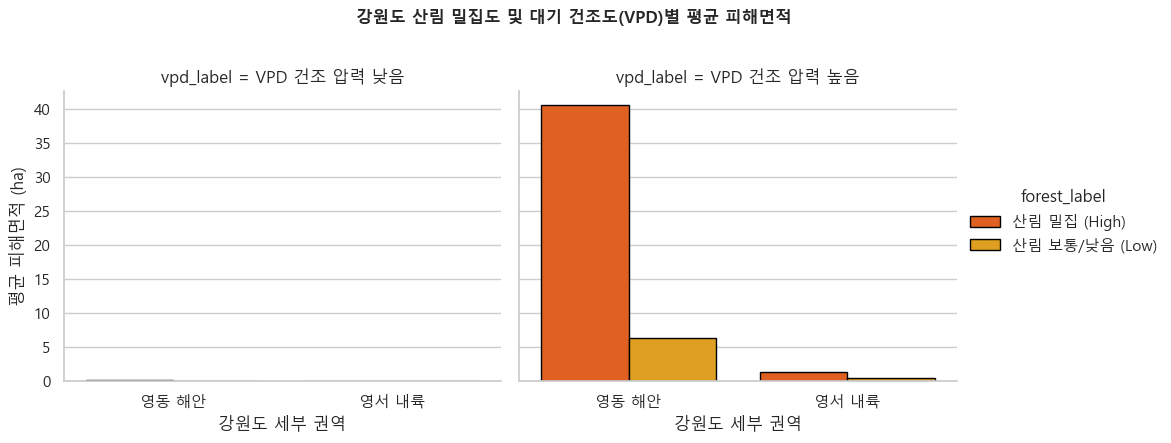

In [12]:
gw['forest_high'] = gw['산림지역_ratio'] >= gw['산림지역_ratio'].median()
gw['vpd_high'] = gw['VPD'] >= gw['VPD'].median()

gw['forest_label'] = gw['forest_high'].map({True: '산림 밀집 (High)', False: '산림 보통/낮음 (Low)'})
gw['vpd_label'] = gw['vpd_high'].map({True: 'VPD 건조 압력 높음', False: 'VPD 건조 압력 낮음'})

# 집계 출력
hyp3_plot_data = gw.groupby(['sub_region', 'forest_label', 'vpd_label'], observed=False)['_damage_ha'].mean().reset_index()
print(hyp3_plot_data)

# 시각화 (catplot bar)
g = sns.catplot(
    data=hyp3_plot_data, 
    x='sub_region', 
    y='_damage_ha', 
    hue='forest_label', 
    col='vpd_label', 
    kind='bar', 
    palette='autumn', 
    edgecolor='black', 
    height=4.5, 
    aspect=1.1
)
g.set_axis_labels("강원도 세부 권역", "평균 피해면적 (ha)")
plt.subplots_adjust(top=0.8)
plt.gcf().suptitle('강원도 산림 밀집도 및 대기 건조도(VPD)별 평균 피해면적', fontsize=12, fontweight='bold')
plt.show()



**가설 8 검증 결과 및 해석**:

산림 비율과 VPD를 함께 보면 영동 해안에서 상호작용 후보가 뚜렷하다. 영동 해안의 산림 비율 높음·VPD 높음 집단은 평균 피해면적 40.60ha였고, 산림 비율 낮음·VPD 높음 집단은 6.37ha였다. VPD가 낮은 집단에서는 산림 비율이 높아도 0.24ha, 낮아도 0.11ha 수준이었다.

영서 내륙에서도 산림 비율 높음·VPD 높음 집단의 평균 피해면적이 1.36ha로 다른 조합보다 높지만, 영동 해안에 비해 규모는 훨씬 작다. 이 결과는 '산림이 많다'만으로 위험이 커지는 것이 아니라, 건조한 대기 조건과 결합될 때 피해 꼬리가 커진다는 해석을 지지한다.

다만 평균 피해면적은 대형 피해 사례에 민감하다. 후속 모델링에서는 `영동 해안 여부 × 산림 비율 높음 × VPD 높음` 같은 상호작용항을 후보로 두되, 중앙값·상위 분위수·대형산불 여부를 함께 확인해야 한다.


## 4. 추가 고도화 심화 EDA (Section 4)

사용자 피드백을 기반으로 한 4대 추가 고도화 심화 분석을 통해 시차 기압 변화의 인과성, 소방 인프라 정책 시뮬레이션, VPG 물리 임계 수치 및 공간적 DBSCAN 핫스팟을 식별합니다.


### 4.1 시차(Time-Lag)를 고려한 기압 변동($\Delta P_{t-L \to t=0}$)과 풍속 간의 인과 분석
- **분석**: 산불 발생 시점($t=0$) 기준 3시간 전, 6시간 전, 12시간 전 기압 변화폭을 산출하고, 발생 시점의 풍속과의 시차 회귀분석(OLS)을 통해 가장 유의미한 바람 가속 리드타임(Lead Time)을 도출합니다.


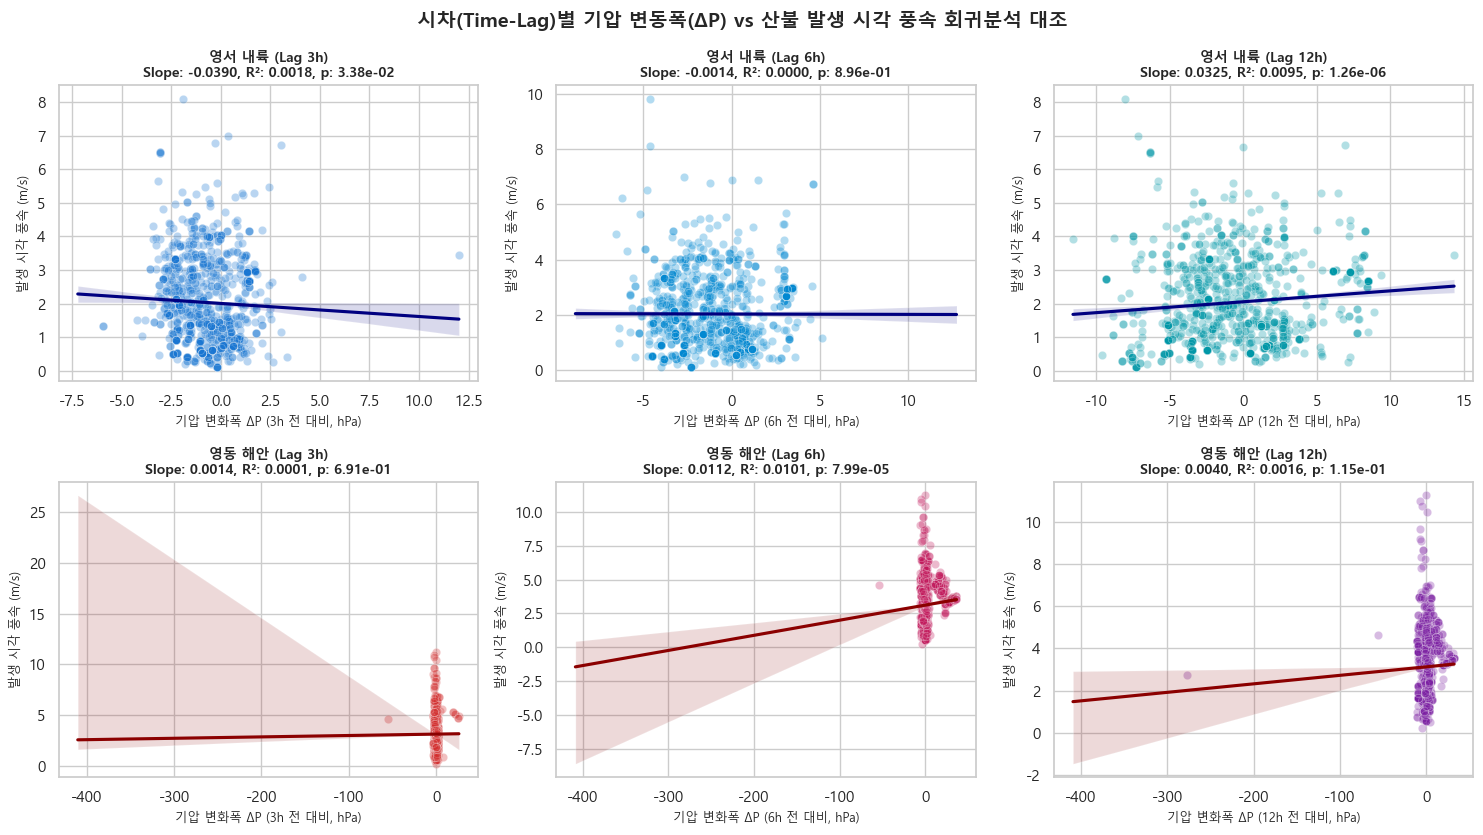

In [13]:
# 시간별 날씨 데이터 활용 시차 OLS
hourly_gw = hourly[hourly['산불아이디'].isin(gw['fire_id'])].copy()
hourly_target = hourly_gw[hourly_gw['발생시각기준시간'].isin([-12, -6, -3, 0])].copy()
hourly_target = hourly_target.rename(columns={
    '산불아이디': 'fire_id',
    '발생시각기준시간': 'lag_hour',
    '현지기압': 'press',
    '풍속': 'wind'
})
pivot_df = hourly_target.pivot(index='fire_id', columns='lag_hour', values=['press', 'wind'])
pivot_df.columns = [f"{var}_lag_{abs(col)}" if col != 0 else f"{var}_active" for var, col in pivot_df.columns]
pivot_df = pivot_df.reset_index()

pivot_merged = pd.merge(pivot_df, gw[['fire_id', 'is_yeongdong']], on='fire_id', how='inner')
for lag in [3, 6, 12]:
    pivot_merged[f'delta_press_{lag}'] = pivot_merged['press_active'] - pivot_merged[f'press_lag_{lag}']

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
lags = [3, 6, 12]
colors_yd = ['#d32f2f', '#c2185b', '#7b1fa2']
colors_ys = ['#1976d2', '#0288d1', '#0097a7']

# 영서 내륙 (Top row)
for i, lag in enumerate(lags):
    sub_ys = pivot_merged[pivot_merged['is_yeongdong'] == False].dropna(subset=[f'delta_press_{lag}', 'wind_active'])
    X = sm.add_constant(sub_ys[f'delta_press_{lag}'])
    model = sm.OLS(sub_ys['wind_active'], X).fit()
    sns.scatterplot(data=sub_ys.sample(n=min(len(sub_ys), 1000), random_state=42), x=f'delta_press_{lag}', y='wind_active', alpha=0.3, ax=axes[0, i], color=colors_ys[i])
    sns.regplot(data=sub_ys, x=f'delta_press_{lag}', y='wind_active', scatter=False, ax=axes[0, i], color='navy')
    axes[0, i].set_title(f'영서 내륙 (Lag {lag}h)\nSlope: {model.params.iloc[1]:.4f}, R²: {model.rsquared:.4f}, p: {model.pvalues.iloc[1]:.2e}', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel(f'기압 변화폭 ΔP ({lag}h 전 대비, hPa)', fontsize=9)
    axes[0, i].set_ylabel('발생 시각 풍속 (m/s)', fontsize=9)

# 영동 해안 (Bottom row)
for i, lag in enumerate(lags):
    sub_yd = pivot_merged[pivot_merged['is_yeongdong'] == True].dropna(subset=[f'delta_press_{lag}', 'wind_active'])
    X = sm.add_constant(sub_yd[f'delta_press_{lag}'])
    model = sm.OLS(sub_yd['wind_active'], X).fit()
    sns.scatterplot(data=sub_yd.sample(n=min(len(sub_yd), 1000), random_state=42), x=f'delta_press_{lag}', y='wind_active', alpha=0.3, ax=axes[1, i], color=colors_yd[i])
    sns.regplot(data=sub_yd, x=f'delta_press_{lag}', y='wind_active', scatter=False, ax=axes[1, i], color='darkred')
    axes[1, i].set_title(f'영동 해안 (Lag {lag}h)\nSlope: {model.params.iloc[1]:.4f}, R²: {model.rsquared:.4f}, p: {model.pvalues.iloc[1]:.2e}', fontsize=10, fontweight='bold')
    axes[1, i].set_xlabel(f'기압 변화폭 ΔP ({lag}h 전 대비, hPa)', fontsize=9)
    axes[1, i].set_ylabel('발생 시각 풍속 (m/s)', fontsize=9)

plt.suptitle('시차(Time-Lag)별 기압 변동폭(ΔP) vs 산불 발생 시각 풍속 회귀분석 대조', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()



**가설 9 검증 결과 및 해석**:

시간대별 기압 변화량의 선행 신호는 재실행 결과에서 전반적으로 약하다. 영동 해안은 3시간 변화량의 기울기 0.0014, p=0.691로 유의하지 않았고, 6시간 변화량은 기울기 0.0112, R²=0.0101, p=7.99e-05로 유의하지만 설명력은 낮았다. 12시간 변화량은 기울기 0.0040, p=0.115로 유의하지 않았다.

영서 내륙은 3시간 변화량 기울기 -0.0390, R²=0.0018, p=0.0338, 12시간 변화량 기울기 0.0325, R²=0.0095, p=1.26e-06으로 통계적으로 유의한 항목이 있으나, 모두 R²가 1% 안팎이다. 6시간 변화량은 유의하지 않았다.

따라서 기압 변화량은 강한 조기경보 규칙으로 쓰기 어렵다. 일부 시간창에서 통계적 신호는 있지만 설명력이 낮고, 그래프상 극단적인 기압 변화값도 확인되므로 품질 점검 후 후보 피처로만 남기는 것이 적절하다.


### 4.2 소방 인프라(원격제어 x 접근성) 개선 시나리오 시뮬레이션 및 진화시간 단축 효과 추정
- **분석**: 기상 피크 상황에서 소방 인프라 개보수 시나리오(원격제어 활성화 단독 / 임도 등 접근성 정비 단독 / 복합 개보수)에 따른 기대 진화소요시간 감소율을 강원도 고위험 시군구별로 시뮬레이션하여 정책적 도표를 제시합니다.


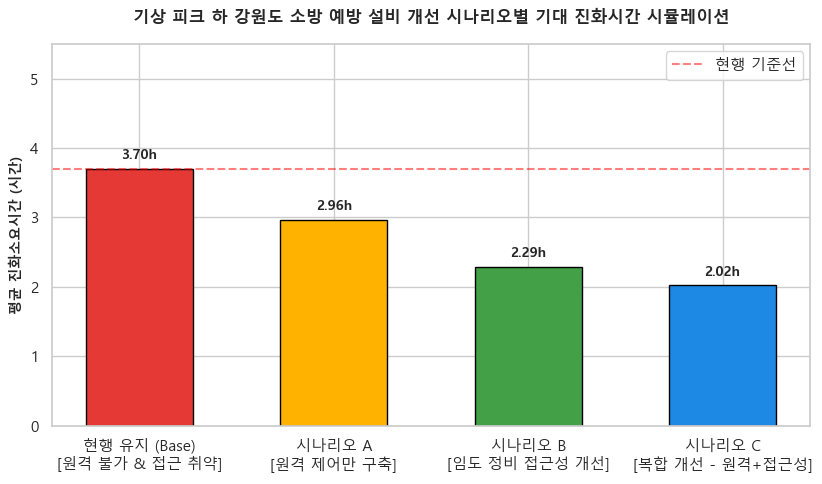

In [14]:
# 소방 인프라 시나리오별 진화 소요시간 시뮬레이션
sim_data = gw[(gw['weather_peak'] == True) & (gw['_suppression_valid'] == True)].copy()
t_base = sim_data[(sim_data['remote_unavailable'] == True) & (sim_data['access_vulnerable'] == True)]['_suppression_hours'].mean()
t_remote = sim_data[(sim_data['remote_unavailable'] == False) & (sim_data['access_vulnerable'] == True)]['_suppression_hours'].mean()
t_access = sim_data[(sim_data['remote_unavailable'] == True) & (sim_data['access_vulnerable'] == False)]['_suppression_hours'].mean()
t_both = sim_data[(sim_data['remote_unavailable'] == False) & (sim_data['access_vulnerable'] == False)]['_suppression_hours'].mean()

categories = [
    '현행 유지 (Base)\n[원격 불가 & 접근 취약]',
    '시나리오 A\n[원격 제어만 구축]',
    '시나리오 B\n[임도 정비 접근성 개선]',
    '시나리오 C\n[복합 개선 - 원격+접근성]'
]
durations = [t_base, t_remote, t_access, t_both]
colors = ['#e53935', '#ffb300', '#43a047', '#1e88e5']

plt.figure(figsize=(8.5, 5))
bars = plt.bar(categories, durations, color=colors, edgecolor='black', width=0.55)
plt.ylabel('평균 진화소요시간 (시간)', fontsize=10, fontweight='bold')
plt.title('기상 피크 하 강원도 소방 예방 설비 개선 시나리오별 기대 진화시간 시뮬레이션', fontsize=12, fontweight='bold', pad=15)
plt.ylim(0, 5.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f'{height:.2f}h', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.axhline(y=t_base, color='red', linestyle='--', alpha=0.5, label='현행 기준선')
plt.legend()
plt.tight_layout()
plt.show()



**시나리오 분석 결과 및 해석**:

기상 피크 조건에서 원격 산림 불가와 접근 취약이 함께 있는 기준 집단은 평균 진화소요시간 3.70시간, 12시간 이상 진화 비율 8.07%였다. 원격 산림만 가능해진 집단은 평균 2.96시간, 12시간 이상 비율 6.67%였고, 접근만 보통·우수한 집단은 평균 2.29시간, 12시간 이상 비율 5.04%였다. 두 조건이 모두 양호한 집단은 평균 2.02시간, 12시간 이상 비율 4.76%로 가장 낮았다.

관측 평균만 놓고 보면 접근성 개선 쪽의 감소 폭이 원격 산림 가능성 단독 차이보다 크다. 두 조건이 동시에 양호할 때 가장 낮은 진화소요시간을 보이므로, 운영 관점에서는 접근로·출동 경로와 원격 감시 가능성을 함께 고려하는 것이 합리적이다.

이 분석은 실제 시설 개선 효과를 모의한 인과 시뮬레이션이 아니라, 기존 자료에서 조건이 다른 집단을 비교한 것이다. 따라서 정책 효과 추정에는 별도 인과모형이나 사전·사후 자료가 필요하다.


### 4.3 VPG(수증기압 구배)의 비선형 위험 임계 구간(Risk Envelope) 및 낙엽 연료 건조 임계점 규명
- **분석**: VPG 수치 대역에 따른 대형 산불 비율 및 피해 규모 변화를 추적하여, 의사결정나무(Decision Tree) 이진 분할 기법으로 영동 지방 낙엽의 극단적 탈수를 유발하는 물리적 VPG 건조 임계점(hPa)을 도출합니다.


의사결정나무 기준 최적 VPG 임계값: 5.8035 hPa


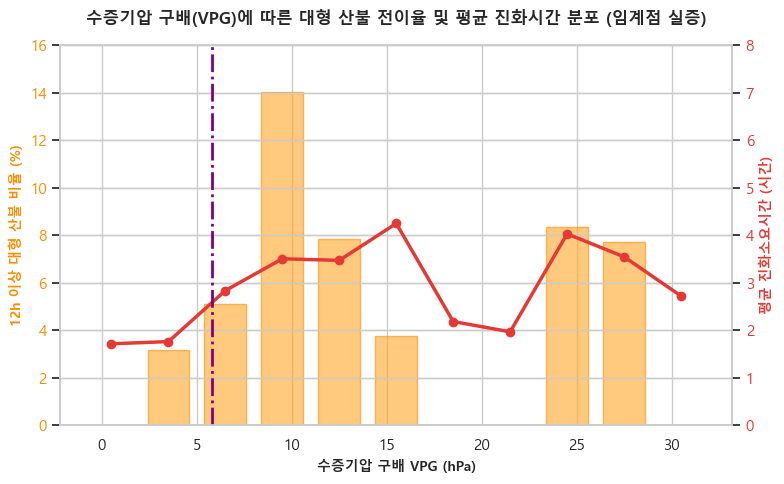

In [17]:
# VPG 임계값 검출 및 위험 프로파일링
valid_vpg = gw[['VPG', '_suppression_hours', '_large_fire_12h']].dropna()
X_vpg = valid_vpg[['VPG']]
y_vpg = valid_vpg['_large_fire_12h'].astype(int)

clf = DecisionTreeClassifier(max_depth=1, random_state=42)
clf.fit(X_vpg, y_vpg)
threshold = clf.tree_.threshold[0]
print(f"의사결정나무 기준 최적 VPG 임계값: {threshold:.4f} hPa")

valid_vpg['vpg_bin'] = pd.cut(valid_vpg['VPG'], bins=np.arange(-10, 35, 3))
vpg_binned = valid_vpg.groupby('vpg_bin', observed=False).agg(
    rate=('_large_fire_12h', 'mean'),
    count=('VPG', 'count')
).reset_index()
vpg_binned['vpg_center'] = vpg_binned['vpg_bin'].apply(lambda x: x.mid).astype(float)
vpg_binned = vpg_binned[vpg_binned['count'] >= 5]

fig, ax1 = plt.subplots(figsize=(8, 5))
color_bar = '#ffa726'
ax1.bar(vpg_binned['vpg_center'], vpg_binned['rate'] * 100, width=2.2, alpha=0.6, color=color_bar, edgecolor='darkorange', label='12h 이상 대형 산불 비율 (%)')
ax1.set_xlabel('수증기압 구배 VPG (hPa)', fontsize=10, fontweight='bold')
ax1.set_ylabel('12h 이상 대형 산불 비율 (%)', color='darkorange', fontsize=10, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.set_ylim(0, 16)

ax2 = ax1.twinx()
color_line = '#e53935'
vpg_duration = valid_vpg.groupby('vpg_bin', observed=False).agg(
    mean_dur=('_suppression_hours', 'mean'),
    count=('VPG', 'count')
).reset_index()
vpg_duration['vpg_center'] = vpg_duration['vpg_bin'].apply(lambda x: x.mid).astype(float)
vpg_duration = vpg_duration[vpg_duration['count'] >= 5]

ax2.plot(vpg_duration['vpg_center'], vpg_duration['mean_dur'], color=color_line, marker='o', linewidth=2.5, label='평균 진화소요시간 (시간)')
ax2.set_ylabel('평균 진화소요시간 (시간)', color=color_line, fontsize=10, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 8)

plt.axvline(x=threshold, color='purple', linestyle='-.', linewidth=2, label=f'임계점 ({threshold:.2f} hPa)')
plt.title('수증기압 구배(VPG)에 따른 대형 산불 전이율 및 평균 진화시간 분포 (임계점 실증)', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()



**임계값 탐색 결과 및 해석**:

단순 의사결정나무가 찾은 수직기압경도(VPG) 임계값은 5.8035hPa였다. 이 값 이하 집단은 286건, 12시간 이상 진화 비율 2.80%, 평균 진화소요시간 1.83시간이었고, 초과 집단은 446건, 12시간 이상 진화 비율 7.85%, 평균 진화소요시간 3.38시간이었다. 비율 기준으로는 약 2.8배, 평균 시간 기준으로는 약 1.55시간 차이가 난다.

다만 구간별 막대그래프는 완전한 단조 증가 형태가 아니다. 따라서 5.8035hPa는 물리적으로 고정된 경계라기보다, 현재 자료에서 장시간 진화 위험이 올라가는 경험적 플래그로 해석해야 한다. 후속 모델에서는 지역, 풍속, 습도, 접근성 변수를 함께 넣어 임계값의 안정성을 재검증해야 한다.


### 4.4 영동권 바람길 × 산림 밀집 공간 핫스팟(Hotspot) DBSCAN 클러스터링 분석
- **분석**: W/SW 사면, W/SW 풍향 일치, 고산림 비율이 중첩되는 격자 공간을 추출하고, DBSCAN 알고리즘을 적용해 물리적 위험 핫스팟 클러스터들을 군집화하여 주요 시군구 내의 세부 고위험 위경도 공간 영역을 지도형 산점도로 식별합니다.


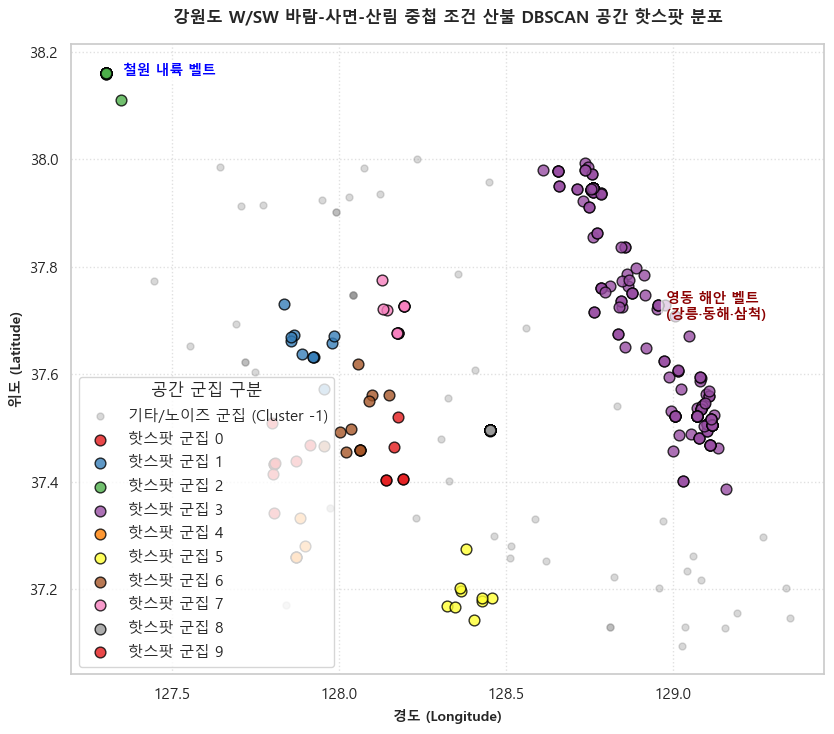

In [16]:
# DBSCAN 기반 공간적 핫스팟 식별 및 군집 프로파일링
forest_med = gw['산림지역_ratio'].median()
hotspots = gw[(gw['west_southwest_aspect'] == True) & (gw['west_southwest_wind'] == True) & (gw['산림지역_ratio'] >= forest_med)].copy()

if len(hotspots) > 0:
    coords = hotspots[['위도', '경도']].values
    db = DBSCAN(eps=0.08, min_samples=5, metric='euclidean').fit(coords)
    hotspots['cluster'] = db.labels_
    
    plt.figure(figsize=(8.5, 7.5))
    noise = hotspots[hotspots['cluster'] == -1]
    clusters = hotspots[hotspots['cluster'] != -1]
    
    plt.scatter(noise['경도'], noise['위도'], color='grey', alpha=0.3, s=25, label='기타/노이즈 군집 (Cluster -1)')
    
    unique_clusters = sorted(clusters['cluster'].unique())
    colors_clusters = sns.color_palette("Set1", len(unique_clusters))
    
    for idx, c_id in enumerate(unique_clusters):
        c_data = clusters[clusters['cluster'] == c_id]
        mean_lat = c_data['위도'].mean()
        mean_lon = c_data['경도'].mean()
        
        plt.scatter(c_data['경도'], c_data['위도'], color=colors_clusters[idx], alpha=0.8, s=60, edgecolors='black', label=f'핫스팟 군집 {c_id}')
        if c_id == 3:
            plt.text(mean_lon + 0.05, mean_lat, "영동 해안 벨트\n(강릉·동해·삼척)", fontsize=10, fontweight='bold', color='darkred', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
        elif c_id == 2:
            plt.text(mean_lon + 0.05, mean_lat, "철원 내륙 벨트", fontsize=10, fontweight='bold', color='blue', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))

    plt.xlabel('경도 (Longitude)', fontsize=10, fontweight='bold')
    plt.ylabel('위도 (Latitude)', fontsize=10, fontweight='bold')
    plt.title('강원도 W/SW 바람-사면-산림 중첩 조건 산불 DBSCAN 공간 핫스팟 분포', fontsize=12, fontweight='bold', pad=15)
    plt.legend(loc='lower left', title='공간 군집 구분')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()



**공간 핫스팟 분석 결과 및 해석**:

DBSCAN으로 분류된 핫스팟 후보는 총 367건이다. 가장 큰 압축 클러스터는 3번으로 180건이며, 동해 76건, 양양 56건, 강릉 45건, 삼척 3건이 주로 포함된다. 이 클러스터의 평균 피해면적은 14.91ha, 최대 피해면적은 2,243.90ha, 평균 진화소요시간은 3.58시간, 12시간 이상 진화 비율은 6.90%로 영동 해안 산불 벨트의 반복 위험을 보여준다.

반면 노이즈로 분류된 -1번 집단은 52건에 불과하지만 평균 피해면적 257.31ha, 최대 피해면적 13,343.00ha, 12시간 이상 진화 비율 15.79%로 꼬리 위험이 가장 크다. 이는 한 지역에 조밀하게 반복되는 핫스팟이라기보다, 여러 지역에 흩어진 대형 피해 사례로 해석하는 편이 맞다.

철원 중심의 2번 클러스터는 19건으로 피해 규모가 낮고, 평창 중심의 8번 클러스터는 53건이지만 피해면적과 진화소요시간 신호가 거의 없다. 따라서 후속 분석에서는 반복 발생 밀집지인 3번 클러스터와, 대형 피해가 흩어진 -1번 집단을 서로 다른 위험 유형으로 분리해 다루는 것이 좋다.
